<a href="https://colab.research.google.com/github/aryaman2603/AryamanGhaisas/blob/main/EDA_CourseProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Loading the dataset using pandas

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/salemprakash/EDA/main/Data/supermarket_sales.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


2. Applying basic statistical analysis

In [19]:
print("Dataset Information")
df.info()

print("Summary Statistics")
df.describe()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   998 non-null    object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  999 non-null    object 
 13  cogs                     1000 non-null   float64
 14  gross

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,9.990000e+02,1000.000000,999.000000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.973373
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131501e-14,11.708825,1.719309
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.000000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.500000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.000000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.500000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.000000


3. Handling Missing Data

In [20]:
print("Missing Values in Each Column")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     2
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    1
cogs                       0
gross margin percentage    1
gross income               0
Rating                     1
dtype: int64

Total Missing Values: 5


In [21]:
# Numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Categorical columns
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


/tmp/ipykernel_5596/3086819710.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


4. Data Cleaning

In [22]:
# Remove duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("New Dataset Shape:", df.shape)

df.head()

Duplicate Rows: 0
New Dataset Shape: (1000, 17)


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5%,Total,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


5. Data Transformation

In [23]:
# Convert Date column into datetime

df["Date"] = pd.to_datetime(df["Date"])

# Create additional useful features

df["Month"] = df["Date"].dt.month_name()

df["Day"] = df["Date"].dt.day_name()

# Convert Time into datetime

df["Time"] = pd.to_datetime(df["Time"]).dt.time

df.head()

/tmp/ipykernel_5596/1094908764.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/tmp/ipykernel_5596/1094908764.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"]).dt.time


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5%,Total,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating,Month,Day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,February,Friday


6. Univariate analysis with 3 visualizations

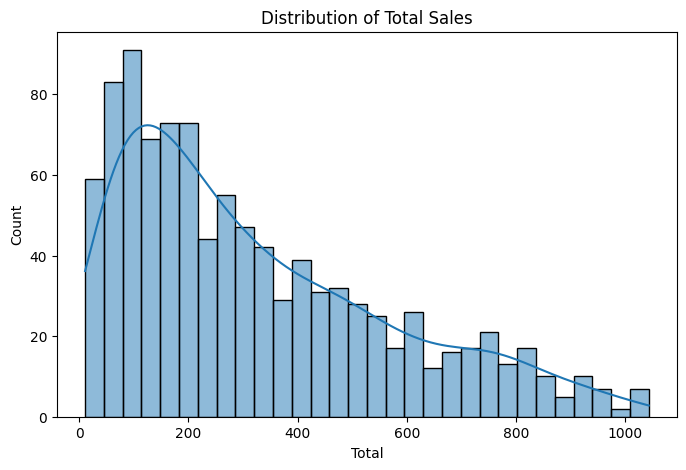

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total"], bins=30, kde=True)

plt.title("Distribution of Total Sales")

plt.show()

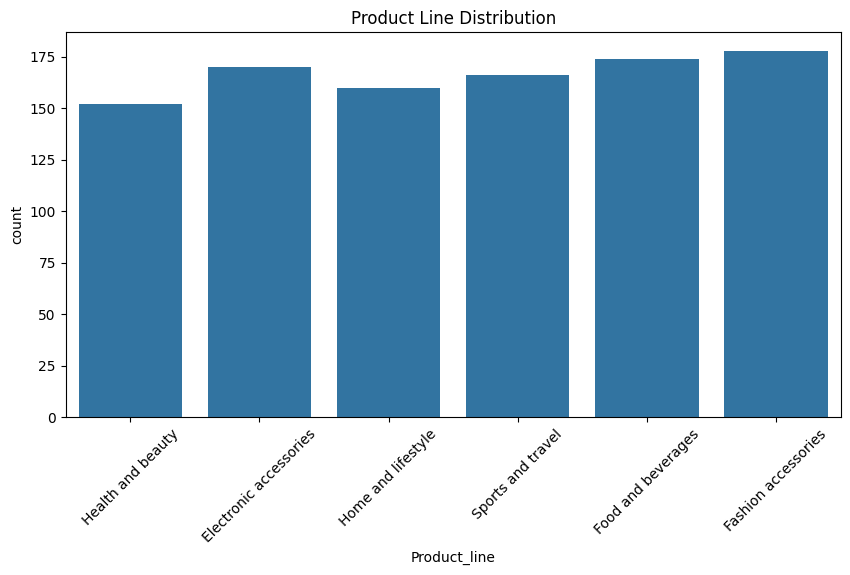

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Product_line")

plt.xticks(rotation=45)

plt.title("Product Line Distribution")

plt.show()

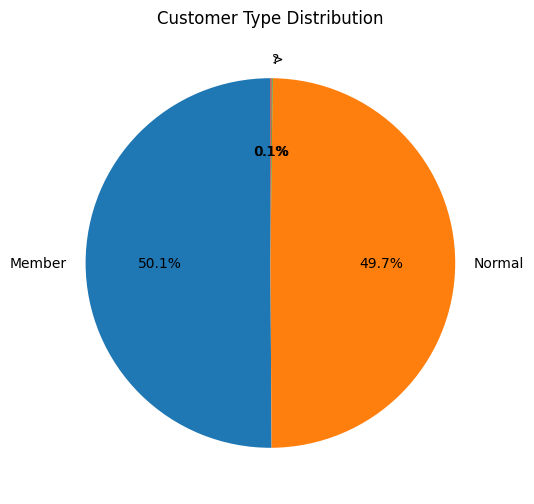

In [26]:
plt.figure(figsize=(6,6))

df["Customer_type"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Customer Type Distribution")

plt.show()

7. Bivariate analysis with 3 visualizations

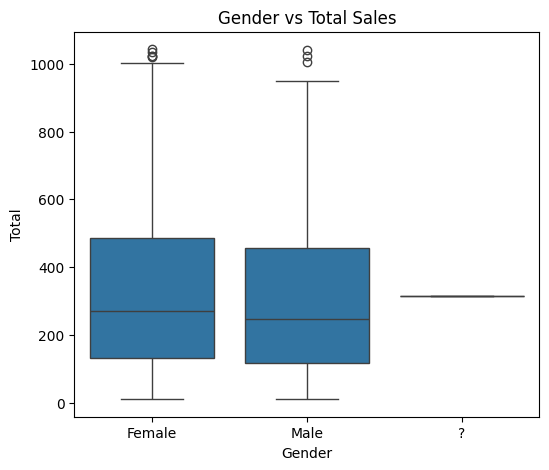

In [27]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="Gender", y="Total")

plt.title("Gender vs Total Sales")

plt.show()

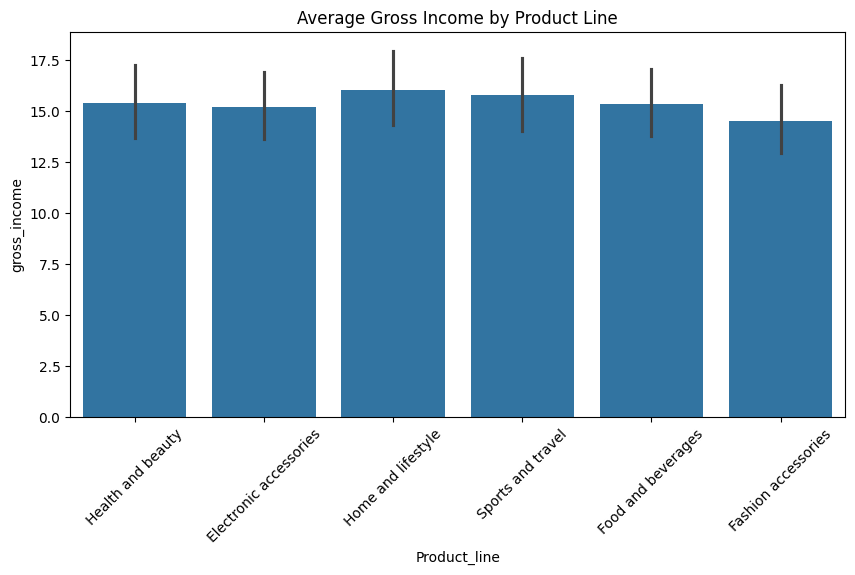

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(data=df, x="Product_line", y="gross_income")

plt.xticks(rotation=45)

plt.title("Average Gross Income by Product Line")

plt.show()

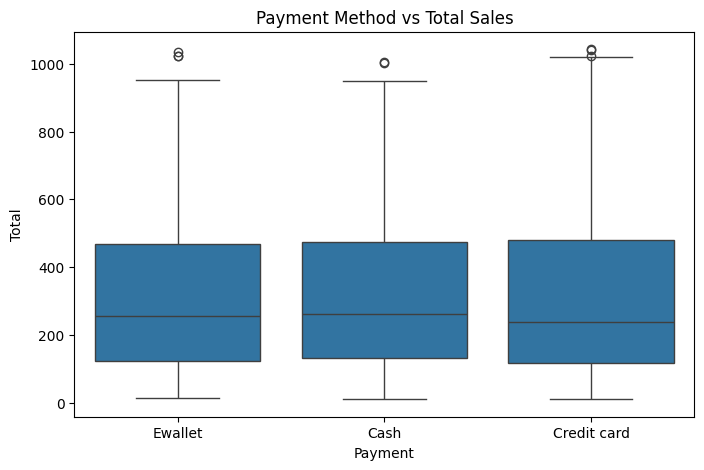

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Payment", y="Total")

plt.title("Payment Method vs Total Sales")

plt.show()

8. Multivariate Analysis with 3 visualizations

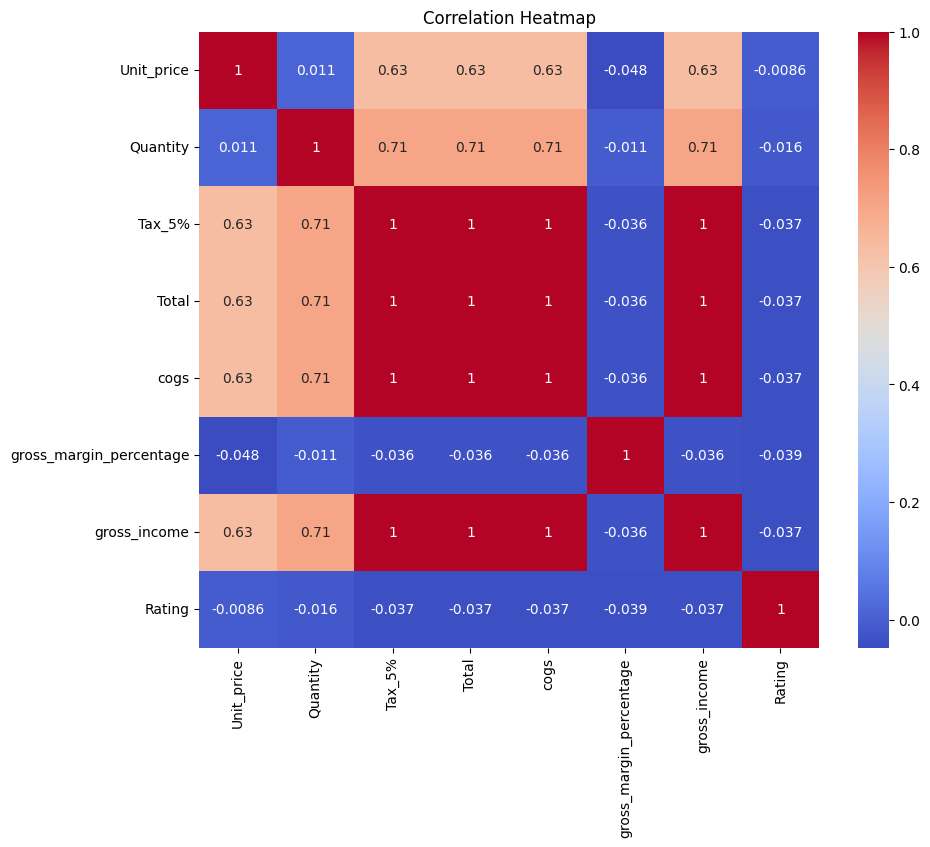

In [30]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

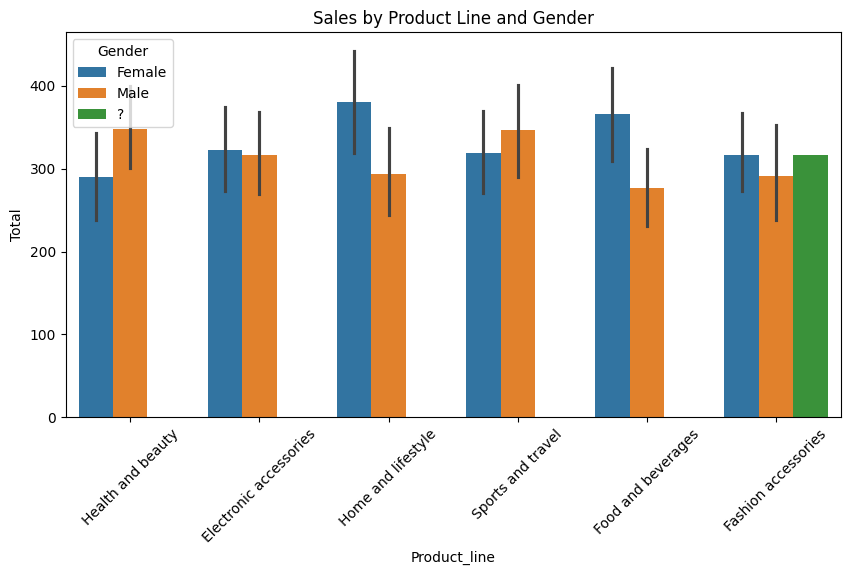

In [31]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Product_line",
    y="Total",
    hue="Gender"
)

plt.xticks(rotation=45)

plt.title("Sales by Product Line and Gender")

plt.show()

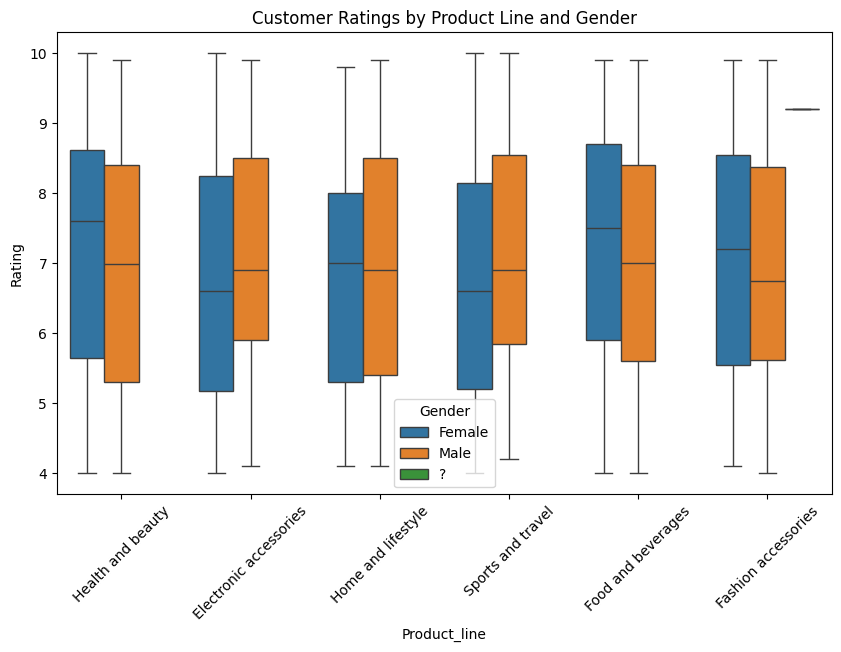

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Product_line",
    y="Rating",
    hue="Gender"
)

plt.xticks(rotation=45)

plt.title("Customer Ratings by Product Line and Gender")

plt.show()

## Phase 2 of Course Project

In [33]:
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1D analysis

In [34]:
# summary statistics table
numeric_cols = df.select_dtypes(include=[np.number])

summary_statistics = pd.DataFrame({
    "Mean": numeric_cols.mean(),
    "Median": numeric_cols.median(),
    "Minimum": numeric_cols.min(),
    "Maximum": numeric_cols.max(),
    "Range": numeric_cols.max() - numeric_cols.min(),
    "Variance": numeric_cols.var(),
    "Standard_Deviation": numeric_cols.std(),
    "IQR": numeric_cols.quantile(0.75) - numeric_cols.quantile(0.25),
    "Skewness": numeric_cols.apply(lambda x: stats.skew(x.dropna())),
    "Kurtosis": numeric_cols.apply(lambda x: stats.kurtosis(x.dropna())),
})
summary_statistics

/tmp/ipykernel_5596/3598121785.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "Skewness": numeric_cols.apply(lambda x: stats.skew(x.dropna())),
/tmp/ipykernel_5596/3598121785.py:14: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "Kurtosis": numeric_cols.apply(lambda x: stats.kurtosis(x.dropna())),


,Mean,Median,Minimum,Maximum,Range,Variance,Standard_Deviation,IQR,Skewness,Kurtosis
Unit_price,55.672130,55.230000,10.080000,99.960000,8.988000e+01,7.019653e+02,2.649463e+01,45.060000,0.007067,-1.218501
Quantity,5.510000,5.000000,1.000000,10.000000,9.000000e+00,8.546446e+00,2.923431e+00,5.000000,0.012922,-1.215472
Tax_5%,15.379369,12.088000,0.508500,49.650000,4.914150e+01,1.370966e+02,1.170883e+01,16.520375,0.891230,-0.087470
Total,322.966749,253.848000,10.678500,1042.650000,1.031972e+03,6.045960e+04,2.458853e+02,346.927875,0.891230,-0.087470
cogs,307.587380,241.760000,10.170000,993.000000,9.828300e+02,5.483864e+04,2.341765e+02,330.407500,0.891230,-0.087470
gross_margin_percentage,4.761905,4.761905,4.761905,4.761905,8.881784e-16,3.759418e-27,6.131409e-14,0.000000,NaN,NaN
gross_income,15.379369,12.088000,0.508500,49.650000,4.914150e+01,1.370966e+02,1.170883e+01,16.520375,0.891230,-0.087470
Rating,6.973373,7.000000,4.000000,10.000000,6.000000e+00,2.953065e+00,1.718448e+00,3.000000,0.007882,-1.151300


Gender
Male      501
Female    498
?           1
Name: count, dtype: int64
Gender
Male      0.501
Female    0.498
?         0.001
Name: proportion, dtype: float64


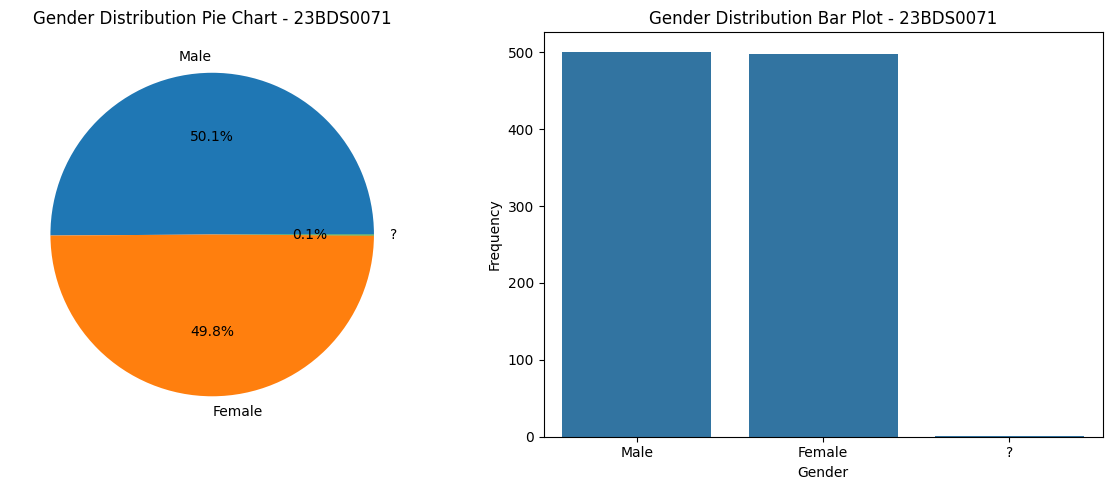

In [35]:
#Frequency for a categorical variable
gender_frequency = df["Gender"].value_counts()
gender_relative_frequency = df["Gender"].value_counts(normalize=True)

print(gender_frequency)
print(gender_relative_frequency)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(gender_frequency, labels=gender_frequency.index, autopct="%1.1f%%")
axes[0].set_title("Gender Distribution Pie Chart - 23BDS0071")

sns.barplot(x=gender_frequency.index, y=gender_frequency.values, ax=axes[1])
axes[1].set_title("Gender Distribution Bar Plot - 23BDS0071")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Quantity
[1, 3)     203
[3, 5)     199
[5, 7)     200
[7, 9)     187
[9, 11)    211
Name: count, dtype: int64


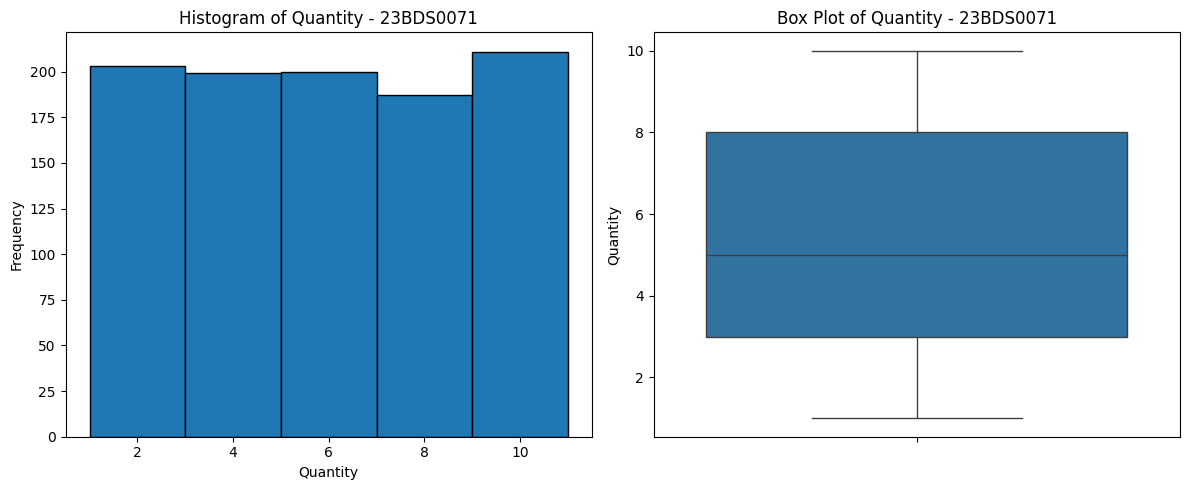

In [36]:
# Binned frequency table for a numeric variable
bins = np.arange(df["Quantity"].min(), df["Quantity"].max() + 3, 2)
quantity_frequency = pd.cut(df["Quantity"], bins=bins, right=False, include_lowest=True).value_counts().sort_index()
print(quantity_frequency)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["Quantity"], bins=bins, edgecolor="black")
axes[0].set_title("Histogram of Quantity - 23BDS0071")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")

sns.boxplot(y=df["Quantity"], ax=axes[1])
axes[1].set_title("Box Plot of Quantity - 23BDS0071")

plt.tight_layout()
plt.show()

In [37]:
# contingency table
branch_gender_table = pd.crosstab(df["Branch"], df["Gender"])
branch_gender_row_percentages = pd.crosstab(df["Branch"], df["Gender"], normalize="index")
branch_gender_column_percentages = pd.crosstab(df["Branch"], df["Gender"], normalize="columns")

print(branch_gender_table)
print(branch_gender_row_percentages)
print(branch_gender_column_percentages)

Gender  ?  Female  Male
Branch                 
A       1     160   179
B       0     161   171
C       0     177   151
Gender         ?    Female      Male
Branch                              
A       0.002941  0.470588  0.526471
B       0.000000  0.484940  0.515060
C       0.000000  0.539634  0.460366
Gender    ?    Female      Male
Branch                         
A       1.0  0.321285  0.357285
B       0.0  0.323293  0.341317
C       0.0  0.355422  0.301397


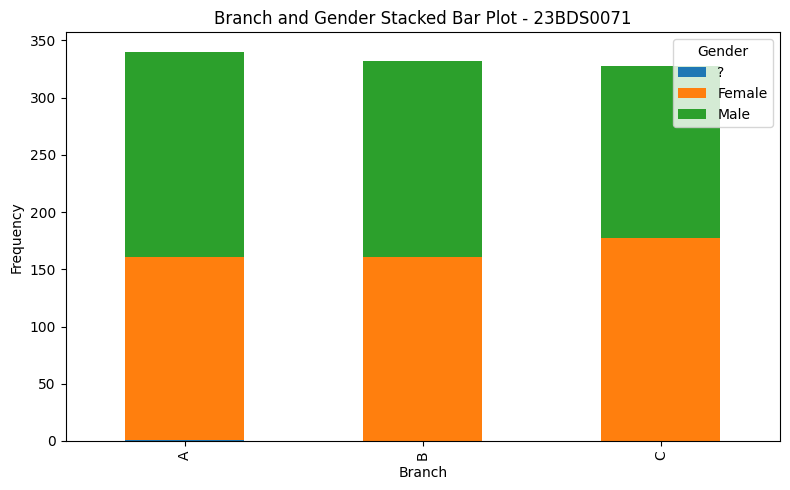

In [38]:
#stacked bar plot
branch_gender_table.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Branch and Gender Stacked Bar Plot - 23BDS0071")
plt.xlabel("Branch")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [40]:
#grouped statistics
grouped_statistics = df.groupby("Product_line")["Total"].agg(
    Total_Mean="mean", Total_Median="median", Total_SD="std"
).reset_index()
grouped_statistics

,Product_line,Total_Mean,Total_Median,Total_SD
0,Electronic accessories,319.632538,241.21650,245.945626
1,Fashion accessories,305.089298,211.64850,243.564130
2,Food and beverages,322.671517,252.48825,247.157780
3,Health and beauty,323.643020,272.30700,237.538815
4,Home and lifestyle,336.636956,258.18975,254.600671
5,Sports and travel,332.065220,270.93150,248.375328


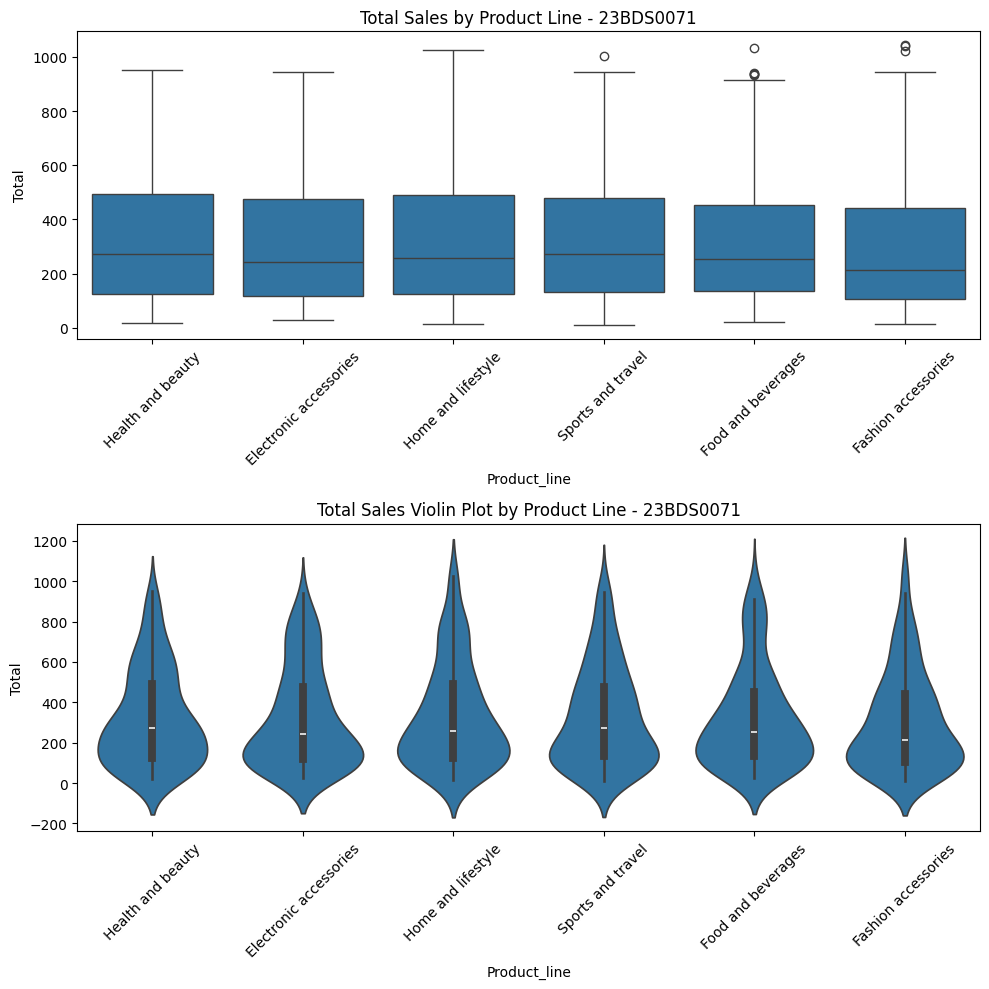

In [42]:
#box plot and violin plot
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.boxplot(x="Product_line", y="Total", data=df, ax=axes[0])
axes[0].set_title("Total Sales by Product Line - 23BDS0071")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(x="Product_line", y="Total", data=df, ax=axes[1])
axes[1].set_title("Total Sales Violin Plot by Product Line - 23BDS0071")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Pearson: 0.6339620885890692
Spearman: 0.6300541064753133


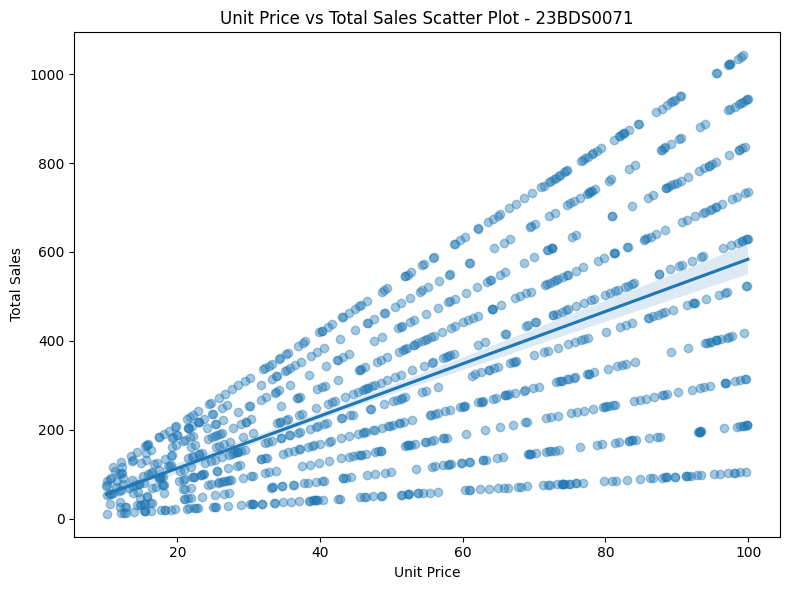

In [43]:
#pearson and spearman correlation
pearson_correlation, _ = stats.pearsonr(df["Unit_price"], df["Total"])
spearman_correlation, _ = stats.spearmanr(df["Unit_price"], df["Total"])
print("Pearson:", pearson_correlation)
print("Spearman:", spearman_correlation)

plt.figure(figsize=(8, 6))
sns.regplot(x="Unit_price", y="Total", data=df, scatter_kws={"alpha": 0.4})
plt.title("Unit Price vs Total Sales Scatter Plot - 23BDS0071")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [44]:
# 2 categorical with 1 numerical analysis
combination_statistics = df.groupby(["Customer_type", "Gender"])["Total"].agg(
    Total_Mean="mean", Total_SD="std"
).reset_index()
combination_statistics

,Customer_type,Gender,Total_Mean,Total_SD
0,>,Male,125.517000,NaN
1,?,Female,293.202000,NaN
2,Member,?,316.470000,NaN
3,Member,Female,336.890878,259.161507
4,Member,Male,318.059073,236.092921
5,Normal,Female,330.208544,237.940658
6,Normal,Male,307.856959,249.865077


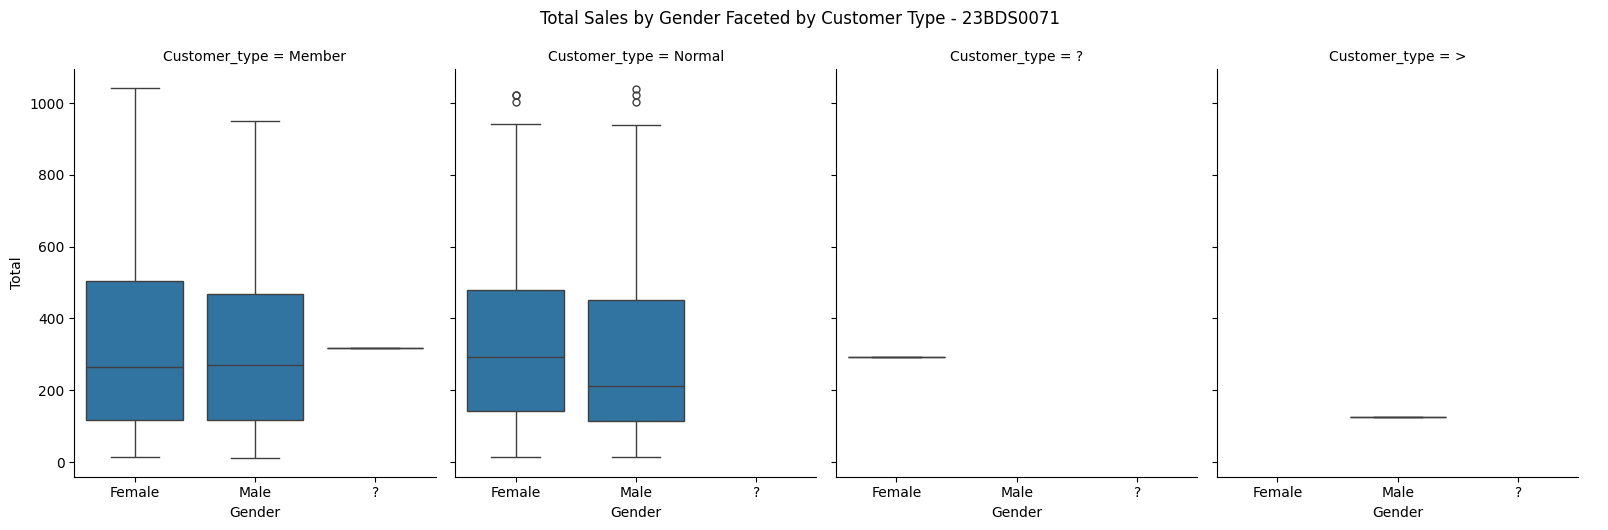

In [45]:
g = sns.catplot(
    x="Gender", y="Total", col="Customer_type",
    data=df, kind="box", height=5, aspect=0.8
)
g.fig.suptitle("Total Sales by Gender Faceted by Customer Type - 23BDS0071", y=1.05)
plt.show()

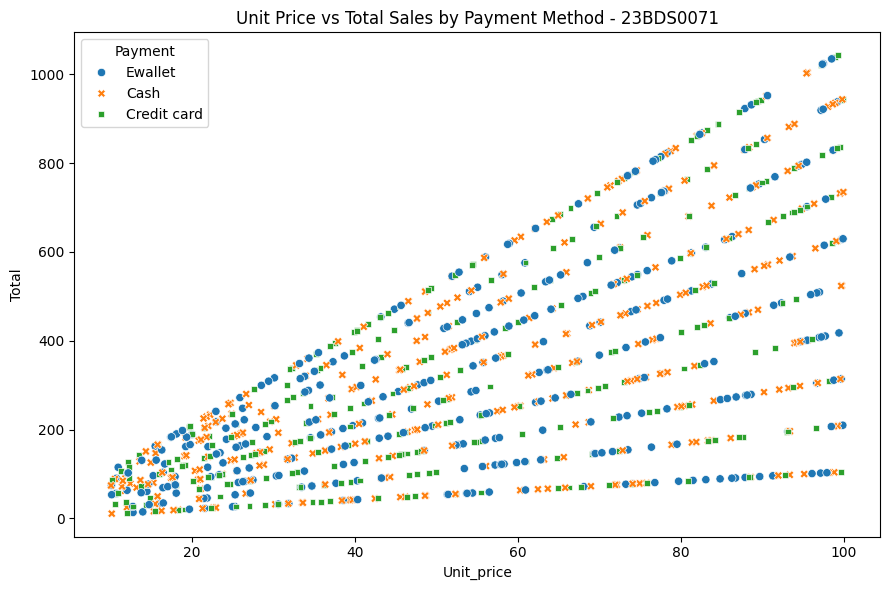


Cash
            Unit_price     Total
Unit_price    1.000000  0.615839
Total         0.615839  1.000000

Credit card
            Unit_price     Total
Unit_price    1.000000  0.669675
Total         0.669675  1.000000

Ewallet
            Unit_price    Total
Unit_price     1.00000  0.62031
Total          0.62031  1.00000


In [46]:
# 1 categorical, 2 numerical analysis
plt.figure(figsize=(9, 6))
sns.scatterplot(x="Unit_price", y="Total", hue="Payment", style="Payment", data=df)
plt.title("Unit Price vs Total Sales by Payment Method - 23BDS0071")
plt.tight_layout()
plt.show()

correlation_by_payment = {
    payment: group[["Unit_price", "Total"]].corr()
    for payment, group in df.groupby("Payment")
}
for payment, corr_matrix in correlation_by_payment.items():
    print(f"\n{payment}")
    print(corr_matrix)

              Unit_price  Quantity    Tax_5%     Total      cogs  \
Unit_price      1.000000  0.010778  0.633962  0.633962  0.633962   
Quantity        0.010778  1.000000  0.705510  0.705510  0.705510   
Tax_5%          0.633962  0.705510  1.000000  1.000000  1.000000   
Total           0.633962  0.705510  1.000000  1.000000  1.000000   
cogs            0.633962  0.705510  1.000000  1.000000  1.000000   
gross_income    0.633962  0.705510  1.000000  1.000000  1.000000   
Rating         -0.008637 -0.016153 -0.036632 -0.036632 -0.036632   

              gross_income    Rating  
Unit_price        0.633962 -0.008637  
Quantity          0.705510 -0.016153  
Tax_5%            1.000000 -0.036632  
Total             1.000000 -0.036632  
cogs              1.000000 -0.036632  
gross_income      1.000000 -0.036632  
Rating           -0.036632  1.000000  


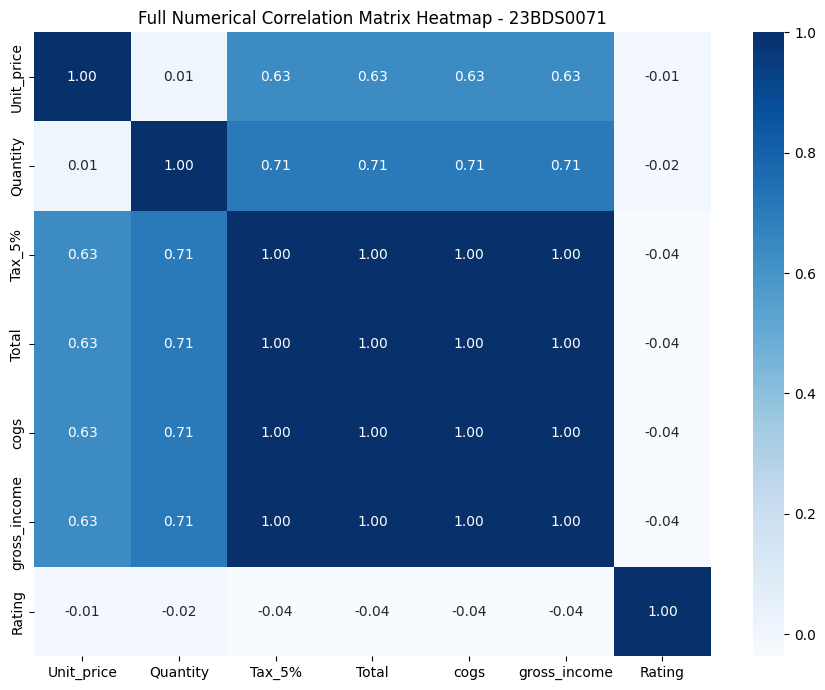

In [47]:
#correlation heatmap
selected_numeric = df[
    ["Unit_price", "Quantity", "Tax_5%", "Total", "cogs", "gross_income", "Rating"]
]
full_correlation_matrix = selected_numeric.corr(method="pearson")
print(full_correlation_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(full_correlation_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Full Numerical Correlation Matrix Heatmap - 23BDS0071")
plt.tight_layout()
plt.show()

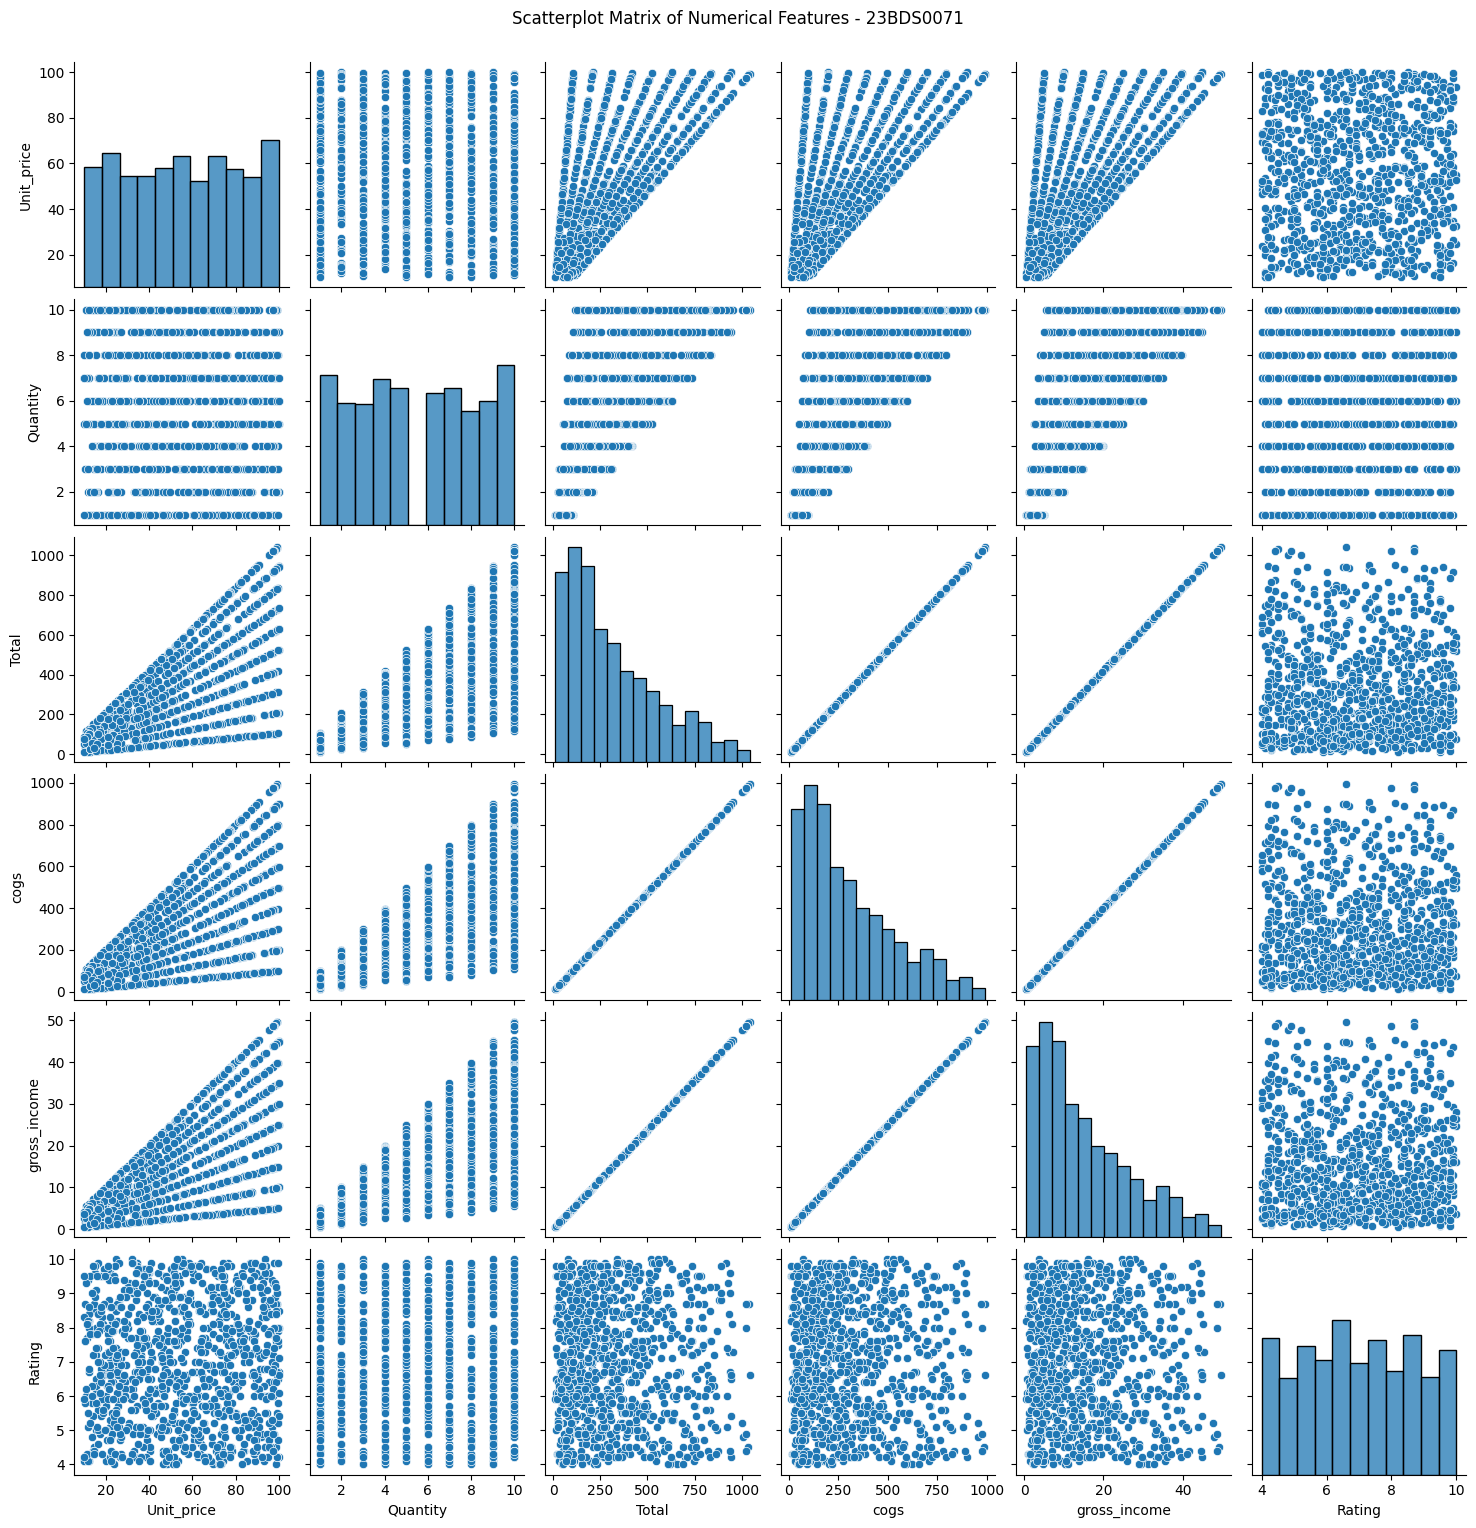

In [48]:
# pairplot
sns.pairplot(
    df[["Unit_price", "Quantity", "Total", "cogs", "gross_income", "Rating"]]
)
plt.suptitle("Scatterplot Matrix of Numerical Features - 23BDS0071", y=1.02)
plt.show()

In [49]:
# K means clustering
kmeans_cols = df.select_dtypes(include=[np.number]).dropna()
scaler = StandardScaler()
kmeans_scaled = scaler.fit_transform(kmeans_cols)
kmeans_scaled_df = pd.DataFrame(kmeans_scaled, columns=kmeans_cols.columns)


if "gross_margin_percentage" in kmeans_scaled_df.columns:
    kmeans_scaled_df = kmeans_scaled_df.drop(columns=["gross_margin_percentage"])

kmeans_2 = KMeans(n_clusters=2, n_init=25, random_state=123)
clusters_2 = kmeans_2.fit_predict(kmeans_scaled_df)

print("Cluster sizes:", np.bincount(clusters_2))
print("Cluster centers:\n", pd.DataFrame(kmeans_2.cluster_centers_, columns=kmeans_scaled_df.columns))

Cluster sizes: [667 333]
Cluster centers:
    Unit_price  Quantity    Tax_5%     Total      cogs  gross_income    Rating
0   -0.390762 -0.404407 -0.602958 -0.602958 -0.602958     -0.602958  0.018709
1    0.782698  0.810028  1.207726  1.207726  1.207726      1.207726 -0.037474


    K         WCSS
0   1  7000.000000
1   2  3453.036964
2   3  2702.536898
3   4  2234.344040
4   5  1903.715884
5   6  1681.290008
6   7  1492.559280
7   8  1343.830857
8   9  1241.628119
9  10  1140.878802


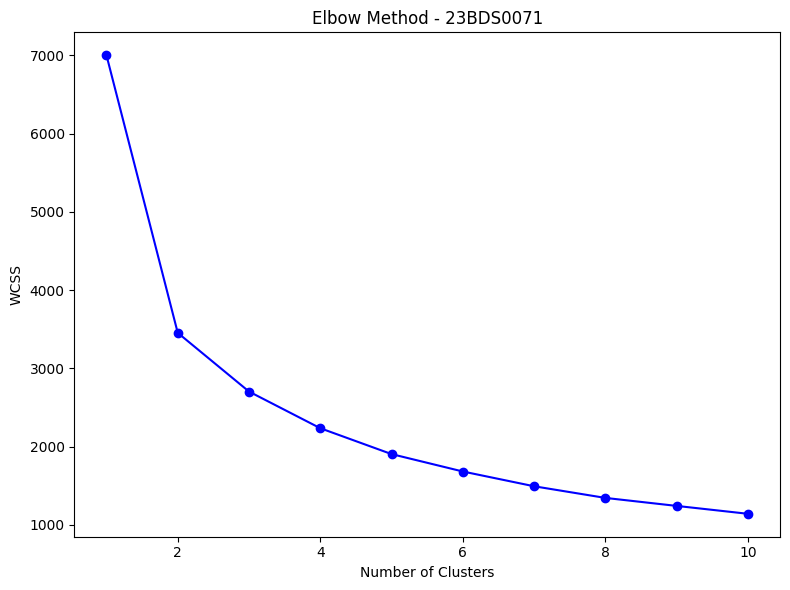

In [50]:
# wcss for k=1 to 10
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=25, random_state=123)
    km.fit(kmeans_scaled_df)
    wcss.append(km.inertia_)

wcss_table = pd.DataFrame({"K": range(1, 11), "WCSS": wcss})
print(wcss_table)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker="o", color="blue")
plt.title("Elbow Method - 23BDS0071")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.show()

In [51]:
# final K means
best_k = 2
final_kmeans = KMeans(n_clusters=best_k, n_init=25, random_state=123)
final_clusters = final_kmeans.fit_predict(kmeans_scaled_df)

aryaman_clustered = kmeans_cols.copy()
aryaman_clustered["Cluster"] = final_clusters
print(aryaman_clustered["Cluster"].value_counts())

Cluster
0    667
1    333
Name: count, dtype: int64


In [52]:
# Hierarchical Clustering
hc_subset = df.iloc[:50]
hc_numeric = hc_subset[["Unit_price", "Quantity", "Tax_5%", "Total", "cogs", "gross_income", "Rating"]].dropna()

scaler_hc = StandardScaler()
hc_scaled = scaler_hc.fit_transform(hc_numeric)

# distance matrix
hc_dist = pdist(hc_scaled, metric="euclidean")

# linkages
single_link = linkage(hc_dist, method="single")
complete_link = linkage(hc_dist, method="complete")
average_link = linkage(hc_dist, method="average")

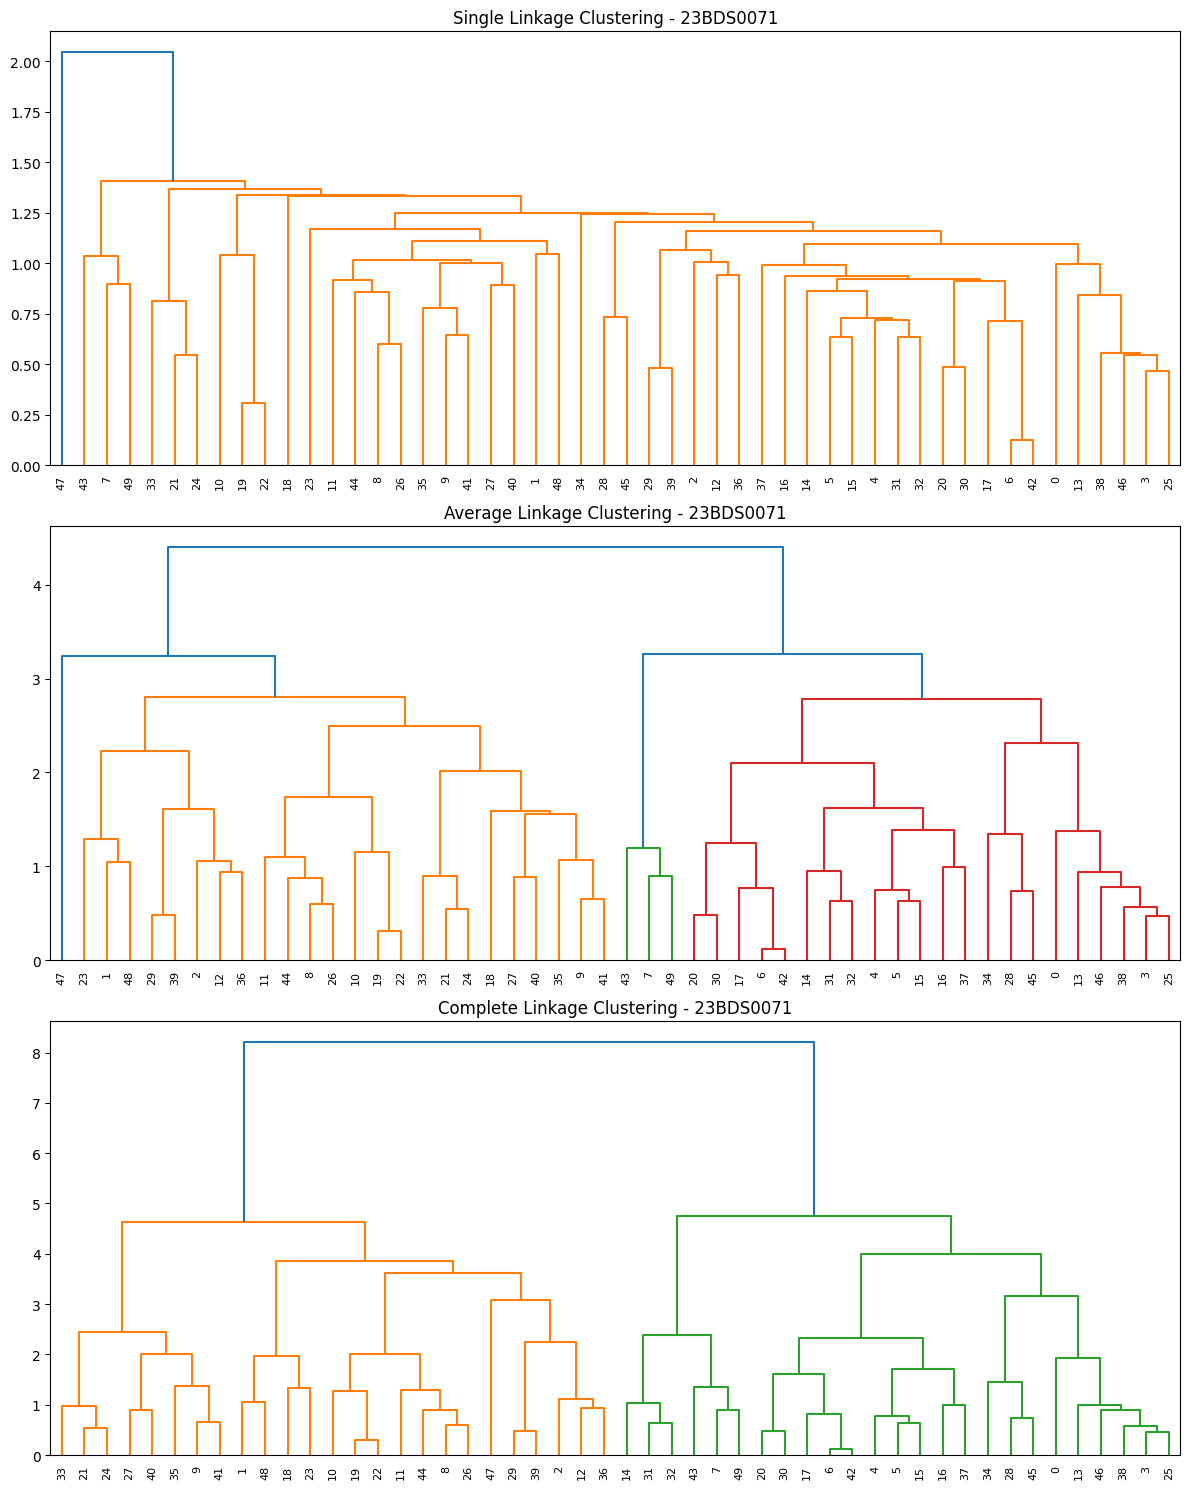

In [53]:
# dendrograms
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

dendrogram(single_link, ax=axes[0], labels=hc_numeric.index.tolist())
axes[0].set_title("Single Linkage Clustering - 23BDS0071")

dendrogram(average_link, ax=axes[1], labels=hc_numeric.index.tolist())
axes[1].set_title("Average Linkage Clustering - 23BDS0071")

dendrogram(complete_link, ax=axes[2], labels=hc_numeric.index.tolist())
axes[2].set_title("Complete Linkage Clustering - 23BDS0071")

plt.tight_layout()
plt.show()

In [54]:
# cut tree into 3 clusters
cluster_assignments = fcluster(complete_link, t=3, criterion="maxclust")
print(cluster_assignments)

cluster_counts = pd.Series(cluster_assignments).value_counts().sort_index()
print(cluster_counts)

[3 1 1 3 3 3 3 2 1 1 1 1 1 3 2 3 3 3 1 1 3 1 1 1 1 3 1 1 3 1 3 2 2 1 3 1 1
 3 3 1 1 1 3 2 1 3 3 1 1 2]
1    25
2     6
3    19
Name: count, dtype: int64
